# Target Variable

In this notebook, we explore the distribution of the target variable, `MHLTH_AdjPrev`.
It represents the age-adjusted prevalence of mental health distress at the county level.

Now, we load the data and visualize the distribution of this variable.

In [1]:
# data loading code is in load_data.py
from load_data import load_places
# get the places data
df_places = load_places()

## 1. Statistics

First, we check the simple statistics.

In [2]:
# see simple statistics
df_places[['MHLTH_AdjPrev']].describe()

,MHLTH_AdjPrev
count,2956.000000
mean,18.607070
std,2.000432
min,12.700000
25%,17.300000
50%,18.600000
75%,19.900000
max,26.600000


The statistics show the mean is 18.6% with a standard deviation 2.0%.
The median (18.6%) is very close to the mean (18.6%).
It suggests a relatively symmetric distribution.

## 2. Histogram

Let's see the distribution.

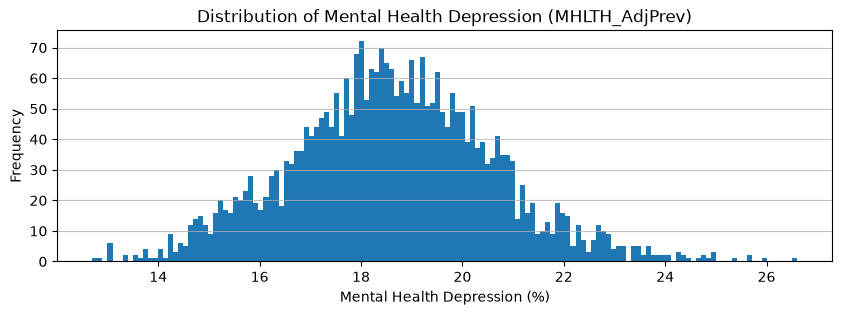

In [3]:
# show MHLTH_AdjPrev distribution
import matplotlib.pyplot as plt
import math

resolution = 10
bins = math.ceil(df_places['MHLTH_AdjPrev'].max() * resolution) - math.floor(df_places['MHLTH_AdjPrev'].min() * resolution) + 1
plt.figure(figsize=(10, 3))
plt.hist(df_places['MHLTH_AdjPrev'].dropna(), bins=bins)
plt.title('Distribution of Mental Health Depression (MHLTH_AdjPrev)')
plt.xlabel('Mental Health Depression (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)



The histogram shows that the distribution of mental health depression prevalence is roughly bell-shaped, and similar to a normal distribution.
It is centered around the mean value (18.6%), with most values concentrated in the inter quartile range (17.3-19.9%), as we've seen in the statistics.

## 3. Outlier with BoxPlot

See outliers with BoxPlot, and shape with Violine plot

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


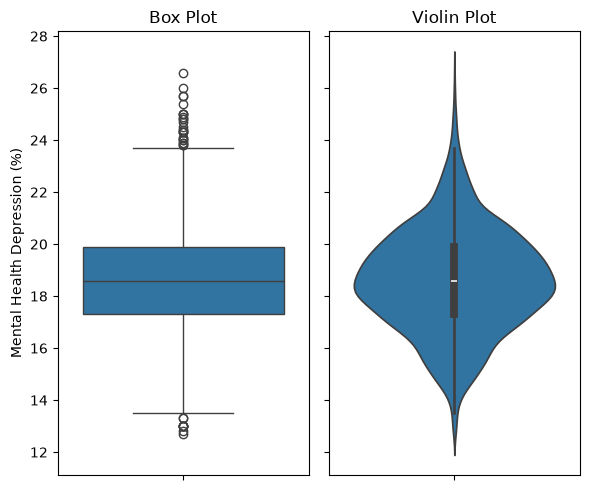

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# share y-axis
fig, axes = plt.subplots(1, 2, figsize=(6, 5), sharey=True)

# boxplot
sns.boxplot(y=df_places["MHLTH_AdjPrev"].dropna(), ax=axes[0])
axes[0].set_title("Box Plot")
axes[0].set_ylabel("Mental Health Depression (%)")

# violinplot
sns.violinplot(y=df_places["MHLTH_AdjPrev"].dropna(), ax=axes[1])
axes[1].set_title("Violin Plot")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

There are several outlisers but it may be small amount comparing to the population.

In [ ]:
data = df_places['MHLTH_AdjPrev'].dropna()

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]

num_outliers = len(outliers)
total_count = len(data)
outlier_percentage = (num_outliers / total_count) * 100

print(f"IQR                      : {IQR:.3f}")
print(f"Boundaries (lower, upper): {lower_bound:.1f}, {upper_bound:.1f}")
print(f"Outlisers                : {num_outliers} / total records: {total_count}")
print(f"Outlier percentage       : {outlier_percentage:.2f}%")

IQR                      : 2.600
boundaries (lower, upper): 13.4, 23.8
outlisers                : 36 / total records: 2956
outlier percentage       : 1.22%


The outliers are only 1.22% of all data, based on the IQR method.
Outlier effect has small impact to overall distribution.

## 4. Choropleth map

Investigate geographical distribution.
The following cell generates choropleth map of the target variable.
Missing or unavailable data are indicated in light gray (gainsboro).
This visualization provides insights into geographic disparities in mental health across different regions.

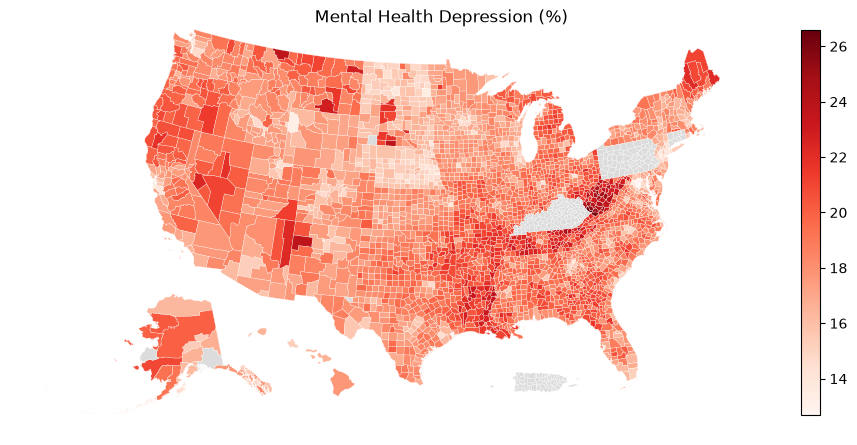

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pygris.utils import shift_geometry

counties = shift_geometry(
    gpd.read_file(
        "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
    )
)

merged = counties.merge(
    df_places,
    left_on="id",
    right_on="CountyFIPS",
    how="left"
)

fig, ax = plt.subplots(figsize=(12, 10))

merged.plot(
    column="MHLTH_AdjPrev",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "shrink": 0.5,
    },
    ax=ax,
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={
        "color": "gainsboro",
        "edgecolor": "white",
        "linewidth": 0.2,
        "label": "No Data",
    },
)
ax.set_axis_off()
ax.set_title(
    "Mental Health Depression (%)",
    x=0.58,
    y=0.95
)

plt.show()

The visualization highlights noticeable geographic disparities.
Higher prevalence rates tend to cluster in specific areas.
In other words, it does not vary randomly.
It motivates our subsequent analysis of underlying socioeconomic relations.